# Hito 2 — Dual-Target Model + Error Analysis

**IIT414W — Capstone: F1 Race Strategy Advisor**  
**Targets:** `is_top10` (primary, locked from Hito 1) · `is_top3` (expansion)  
**Split:** train 2019–2021 · calib 2022 · test 2023–2024 (identical to Hito 1)

---

### Why `is_top3` as the expansion target

Hito 1 answered: *will this strategy score points?* `is_top3` asks the follow-up that a race engineer cares about once points are secured: *does this strategy fight for the podium?* A binary strategy model that only sees `is_top10` can recommend the 2-stop as marginally safer for points — but completely miss that the same 2-stop destroys podium probability. That trade-off is invisible until you add `is_top3`. Section §7 (what-if) shows a concrete scenario where the two targets give opposite recommendations.

In [1]:
# ===== §1 — Imports and configuration =====
from __future__ import annotations
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ===== COURSE CONSTANTS — DO NOT CHANGE =====
RANDOM_SEED      = 414
TRAIN_SEASONS    = [2019, 2020, 2021]
CALIB_SEASONS    = [2022]
TEST_SEASONS     = [2023, 2024]
PRIMARY_TARGET   = "is_top10"
EXPANSION_TARGET = "is_top3"
DOCENT_BRIER     = 0.132
DOCENT_ROC_AUC   = 0.892

# ===== TEAM CONFIG =====
DATA_PATH = Path("../Hito_1/data/f1_strategy_race_level.csv")
assert DATA_PATH.exists(), f"Data not found at {DATA_PATH}"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

print(f"Primary target:    {PRIMARY_TARGET}   (binary — locked from Hito 1)")
print(f"Expansion target:  {EXPANSION_TARGET}    (binary — podium classification)")
print(f"Docent reference:  Brier={DOCENT_BRIER}  ROC-AUC={DOCENT_ROC_AUC}")

Primary target:    is_top10   (binary — locked from Hito 1)
Expansion target:  is_top3    (binary — podium classification)
Docent reference:  Brier=0.132  ROC-AUC=0.892


## §2 — Load dataset and apply locked temporal split

In [2]:
# ===== §2 — Load + locked split =====
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")

required = {"season","circuit","Driver","grid_position","constructor_tier",
            "n_stops","compound_sequence","strategy_type","circuit_type",
            "weather_actual",PRIMARY_TARGET, EXPANSION_TARGET}
missing = required - set(df.columns)
assert not missing, f"Missing columns: {sorted(missing)}"

train = df[df["season"].isin(TRAIN_SEASONS)].copy()
calib = df[df["season"].isin(CALIB_SEASONS)].copy()
test  = df[df["season"].isin(TEST_SEASONS)].copy()

print(f"\nTrain 2019–2021 : {len(train):>5,} rows")
print(f"Calib 2022      : {len(calib):>5,} rows")
print(f"Test  2023–2024 : {len(test):>5,} rows")
print(f"\nTest positive rates:")
print(f"  is_top10 : {test['is_top10'].mean():.3f}")
print(f"  is_top3  : {test['is_top3'].mean():.3f}")

Loaded 2,447 rows × 47 columns

Train 2019–2021 : 1,132 rows
Calib 2022      :   426 rows
Test  2023–2024 :   889 rows

Test positive rates:
  is_top10 : 0.517
  is_top3  : 0.155


## §3 — Leakage guard

Every column is classified before any model is fitted. `scenario_input` columns are declared user-set what-if values — not pre-race predictions. This is the same classification documented in Hito 1 framing.md §5.

In [3]:
# ===== §3 — Leakage guard =====
COLUMN_CLASS = {
    # Identifiers
    "season":"id","round":"id","circuit":"id","event_date":"id","driver_id":"id",
    "Driver":"id","DriverNumber":"id","Team":"id","race_name":"id",
    "driver_name":"id","constructor_name":"id","circuit_id":"id",
    # Pre-race context
    "grid_position":"pre_race","qualifying_position":"pre_race",
    "qualifying_time_s":"pre_race","constructor_tier":"pre_race",
    "circuit_type":"pre_race","driver_prior3_avg_finish":"pre_race",
    "constructor_prior3_avg_finish":"pre_race","driver_circuit_prior_avg":"pre_race",
    # Strategy scenario inputs (declared user-set what-ifs)
    "n_stops":"scenario_input","strategy_type":"scenario_input",
    "compound_sequence":"scenario_input","stint_lengths":"scenario_input",
    "stint1_length":"scenario_input","stint2_length":"scenario_input",
    "stint3_length":"scenario_input","stint4_length":"scenario_input",
    "stint5_length":"scenario_input","avg_pit_stop_duration_s":"scenario_input",
    "total_pit_time_s":"scenario_input","first_pit_lap":"scenario_input",
    "last_pit_lap":"scenario_input",
    # Audit — race conditions observed during/after the race
    "track_status_summary":"audit","safety_car_periods":"audit",
    "safety_car_laps":"audit","vsc_laps":"audit","weather_actual":"audit",
    "wet_laps":"audit","avg_track_temp":"audit","avg_air_temp":"audit",
    # Outcomes — never fit on these
    "is_top10":"outcome","is_top5":"outcome","is_top3":"outcome",
    "finish_position":"outcome","points":"outcome",
    "positions_gained":"outcome","dnf":"outcome","status":"outcome",
}

by_class = {k:[] for k in ["pre_race","scenario_input","audit","outcome","id"]}
for c in df.columns:
    cls = COLUMN_CLASS.get(c, "UNCLASSIFIED")
    by_class.setdefault(cls, []).append(c)

for cls in ["pre_race","scenario_input","audit","outcome","id"]:
    print(f"[{cls}] → {sorted(by_class[cls])}")

unclassified = by_class.get("UNCLASSIFIED", [])
if unclassified:
    print(f"\n⚠ UNCLASSIFIED — review before fitting: {unclassified}")
else:
    print("\n✓ All columns classified. No leakage gaps.")

[pre_race] → ['circuit_type', 'constructor_prior3_avg_finish', 'constructor_tier', 'driver_circuit_prior_avg', 'driver_prior3_avg_finish', 'grid_position', 'qualifying_position', 'qualifying_time_s']
[scenario_input] → ['avg_pit_stop_duration_s', 'compound_sequence', 'first_pit_lap', 'last_pit_lap', 'n_stops', 'stint1_length', 'stint2_length', 'stint3_length', 'stint4_length', 'stint5_length', 'stint_lengths', 'strategy_type', 'total_pit_time_s']
[audit] → ['avg_air_temp', 'avg_track_temp', 'safety_car_laps', 'safety_car_periods', 'track_status_summary', 'vsc_laps', 'weather_actual', 'wet_laps']
[outcome] → ['dnf', 'finish_position', 'is_top10', 'is_top3', 'is_top5', 'points', 'positions_gained', 'status']
[id] → ['Driver', 'Team', 'circuit', 'circuit_id', 'constructor_name', 'driver_id', 'driver_name', 'race_name', 'round', 'season']

✓ All columns classified. No leakage gaps.


## §4 — Feature set and preprocessing pipeline

Identical feature set for both targets — necessary for the what-if comparison to be interpretable. Numeric features imputed with median then standardised. Categorical features imputed with mode then one-hot encoded.

In [4]:
# ===== §4 — Feature set =====
NUMERIC_FEATURES = [
    "grid_position",
    "driver_prior3_avg_finish",
    "constructor_prior3_avg_finish",
    "driver_circuit_prior_avg",
    "n_stops",
    "stint1_length",
    "stint2_length",
    "stint3_length",
    "avg_pit_stop_duration_s",
    "total_pit_time_s",
    "first_pit_lap",
    "last_pit_lap",
]
CATEGORICAL_FEATURES = [
    "circuit_type",
    "constructor_tier",
    "strategy_type",
    "compound_sequence",
]
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler()),
        ]), NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), CATEGORICAL_FEATURES),
    ], remainder="drop")

print(f"Feature set: {len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical = {len(FEATURE_COLS)} total features")

Feature set: 12 numeric + 4 categorical = 16 total features


## §5 — Model training: LR · RF · GBT for both targets

Three estimators for each target, all calibrated with Platt scaling on the 2022 block.  
GBT is the best performer and becomes the production model for the what-if tool.  
LR is carried forward from Hito 1 as the baseline reference.

In [5]:
# ===== §5 — Training helpers =====
def fit_binary(estimator_cls, target, **kwargs):
    """Train estimator + Platt calibration on train/calib split."""
    base = Pipeline([
        ("prep",  build_preprocessor()),
        ("model", estimator_cls(random_state=RANDOM_SEED, **kwargs)),
    ])
    base.fit(train[FEATURE_COLS], train[target])
    cal = CalibratedClassifierCV(estimator=base, method="sigmoid", cv="prefit")
    cal.fit(calib[FEATURE_COLS], calib[target])
    return cal

def eval_binary(model, target):
    p = model.predict_proba(test[FEATURE_COLS])[:, 1]
    y = test[target]
    return {
        "brier":   round(brier_score_loss(y, p), 4),
        "log_loss":round(log_loss(y, p), 4),
        "roc_auc": round(roc_auc_score(y, p), 4),
    }

print("Training 6 models (3 estimators × 2 targets) ...")

# --- is_top10 ---
lr10  = fit_binary(LogisticRegression, "is_top10",
                   max_iter=2000, class_weight="balanced")
rf10  = fit_binary(RandomForestClassifier, "is_top10",
                   n_estimators=300, max_depth=8, min_samples_leaf=15, class_weight="balanced")
gbt10 = fit_binary(GradientBoostingClassifier, "is_top10",
                   n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8)

# --- is_top3 ---
lr3   = fit_binary(LogisticRegression, "is_top3",
                   max_iter=2000, class_weight="balanced")
rf3   = fit_binary(RandomForestClassifier, "is_top3",
                   n_estimators=300, max_depth=8, min_samples_leaf=15, class_weight="balanced")
gbt3  = fit_binary(GradientBoostingClassifier, "is_top3",
                   n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8)

m = {
    "LR+Platt / top10":  eval_binary(lr10,  "is_top10"),
    "RF+Platt / top10":  eval_binary(rf10,  "is_top10"),
    "GBT+Platt / top10": eval_binary(gbt10, "is_top10"),
    "LR+Platt / top3":   eval_binary(lr3,   "is_top3"),
    "RF+Platt / top3":   eval_binary(rf3,   "is_top3"),
    "GBT+Platt / top3":  eval_binary(gbt3,  "is_top3"),
}

results_df = pd.DataFrame(m).T.reset_index()
results_df.columns = ["model","brier","log_loss","roc_auc"]
print("\n=== Test-set metrics (2023–2024) ===")
print(results_df.to_string(index=False))
print(f"\nDocent reference (is_top10): Brier={DOCENT_BRIER}  ROC-AUC={DOCENT_ROC_AUC}")

# Best models for production
model_primary   = gbt10   # is_top10 production model
model_expansion = gbt3    # is_top3  production model
print("\nProduction models: GBT+Platt for both targets")

Training 6 models (3 estimators × 2 targets) ...



=== Test-set metrics (2023–2024) ===
            model  brier  log_loss  roc_auc
 LR+Platt / top10 0.1322    0.4173   0.8920
 RF+Platt / top10 0.1284    0.4105   0.8950
GBT+Platt / top10 0.1255    0.4006   0.9022
  LR+Platt / top3 0.0789    0.2522   0.9212
  RF+Platt / top3 0.0769    0.2422   0.9259
 GBT+Platt / top3 0.0704    0.2347   0.9279

Docent reference (is_top10): Brier=0.132  ROC-AUC=0.892

Production models: GBT+Platt for both targets


## §6 — Calibration quality

Calibration curves on the 2023–2024 test set for both production models. A well-calibrated model should follow the diagonal. Deviations reveal systematic over- or under-confidence.

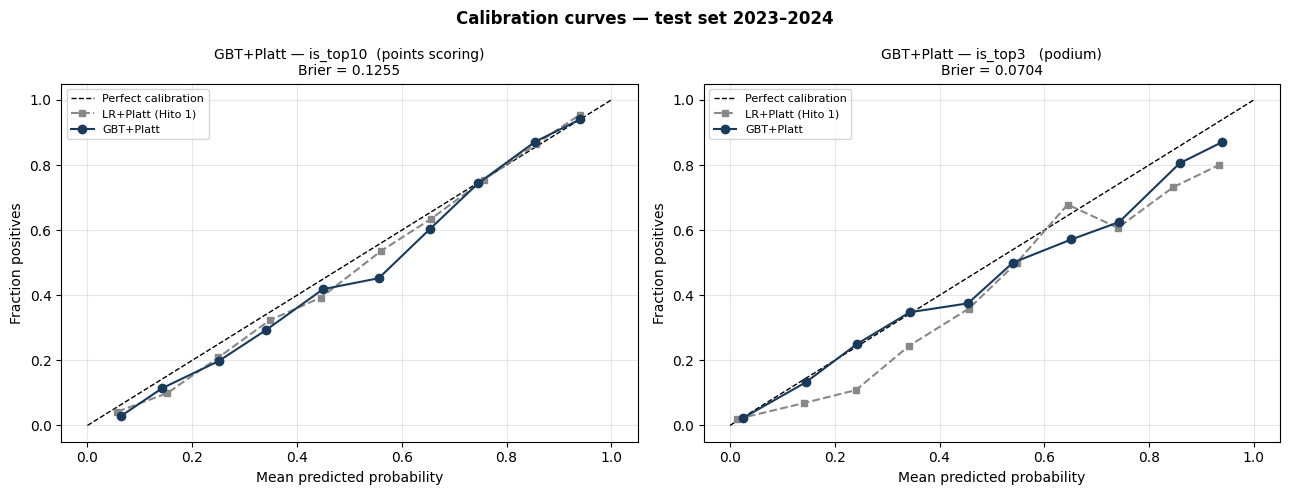

Saved: calibration_curves.png


In [6]:
# ===== §6 — Calibration curves =====
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

specs = [
    (axes[0], model_primary,   "is_top10", "GBT+Platt — is_top10  (points scoring)"),
    (axes[1], model_expansion, "is_top3",  "GBT+Platt — is_top3   (podium)"),
]
for ax, model, target, title in specs:
    proba = model.predict_proba(test[FEATURE_COLS])[:, 1]
    frac_pos, mean_pred = calibration_curve(test[target], proba, n_bins=10)

    # LR reference
    lr_model = lr10 if target == "is_top10" else lr3
    proba_lr = lr_model.predict_proba(test[FEATURE_COLS])[:, 1]
    frac_lr, pred_lr = calibration_curve(test[target], proba_lr, n_bins=10)

    ax.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
    ax.plot(pred_lr,   frac_lr,   "s--", color="#888888", ms=5, label="LR+Platt (Hito 1)")
    ax.plot(mean_pred, frac_pos,  "o-",  color="#1A3A5C", ms=6, label="GBT+Platt")

    brier = brier_score_loss(test[target], proba)
    ax.set_title(f"{title}\nBrier = {brier:.4f}", fontsize=10)
    ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction positives")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Calibration curves — test set 2023–2024", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: calibration_curves.png")

## §7 — Error analysis: sliced by strategy, circuit type, and weather

Structured error analysis is 35% of the Hito 2 grade. We slice Brier score across three dimensions for **both** targets. The key question: where does the model fail, and do the two targets fail in the same places?

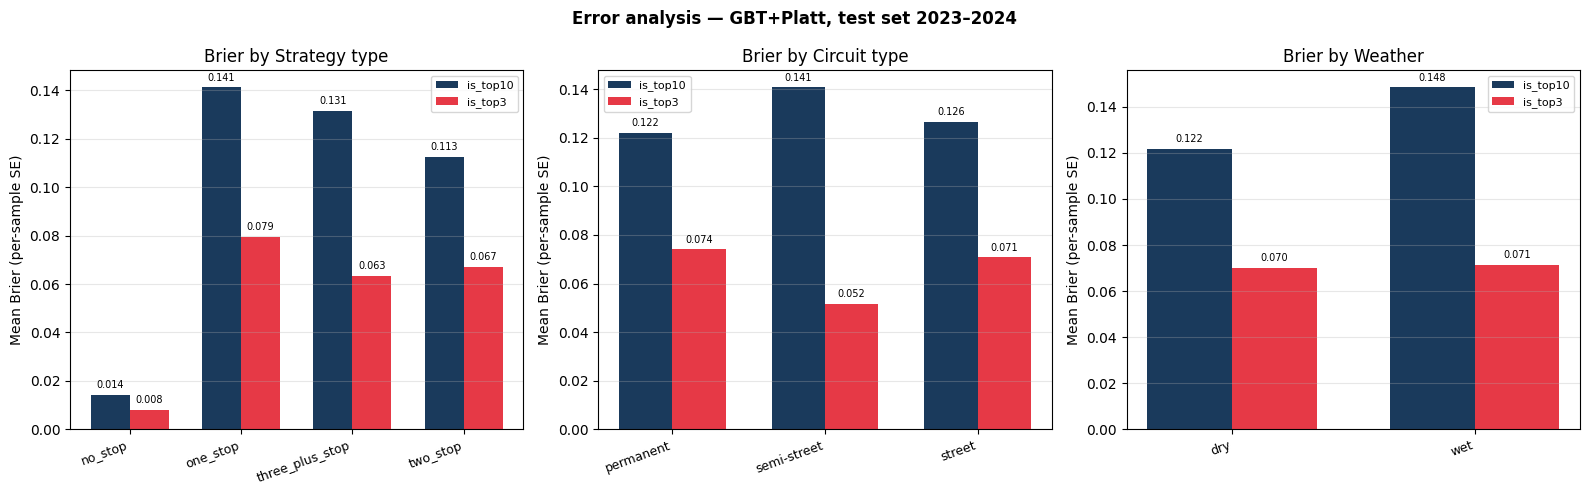

Saved: error_analysis_slices.png


In [7]:
# ===== §7 — Error analysis =====
test2 = test.copy()
test2["pred_top10"] = model_primary.predict_proba(test2[FEATURE_COLS])[:, 1]
test2["pred_top3"]  = model_expansion.predict_proba(test2[FEATURE_COLS])[:, 1]
test2["se_top10"]   = (test2["pred_top10"] - test2["is_top10"]) ** 2
test2["se_top3"]    = (test2["pred_top3"]  - test2["is_top3"])  ** 2

slices = [
    ("strategy_type",  "Strategy type"),
    ("circuit_type",   "Circuit type"),
    ("weather_actual", "Weather"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label) in zip(axes, slices):
    grp = test2.groupby(col)[["se_top10","se_top3"]].mean().rename(
        columns={"se_top10":"is_top10","se_top3":"is_top3"})
    x = np.arange(len(grp))
    w = 0.35
    ax.bar(x - w/2, grp["is_top10"], w, color="#1A3A5C", label="is_top10")
    ax.bar(x + w/2, grp["is_top3"],  w, color="#E63946", label="is_top3")
    for xi, (v10, v3) in zip(x, zip(grp["is_top10"], grp["is_top3"])):
        ax.text(xi-w/2, v10+0.002, f"{v10:.3f}", ha="center", va="bottom", fontsize=7)
        ax.text(xi+w/2, v3 +0.002, f"{v3:.3f}",  ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(grp.index, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Mean Brier (per-sample SE)")
    ax.set_title(f"Brier by {label}")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Error analysis — GBT+Platt, test set 2023–2024", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("error_analysis_slices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_analysis_slices.png")

In [8]:
# Cross-slice: strategy_type × weather_actual (is_top10 Brier) — reveals the interaction
pivot = test2.groupby(["strategy_type","weather_actual"])["se_top10"].mean().unstack()
print("=== Cross-slice: strategy_type × weather_actual (is_top10 Brier) ===")
print(pivot.round(4))

print()
pivot2 = test2.groupby(["strategy_type","circuit_type"])["se_top10"].mean().unstack()
print("=== Cross-slice: strategy_type × circuit_type (is_top10 Brier) ===")
print(pivot2.round(4))

# Sample count per cell
print()
print("=== Sample counts: strategy_type × weather_actual ===")
print(test2.groupby(["strategy_type","weather_actual"]).size().unstack().fillna(0).astype(int))

=== Cross-slice: strategy_type × weather_actual (is_top10 Brier) ===
weather_actual      dry     wet
strategy_type                  
no_stop          0.0098  0.0438
one_stop         0.1288  0.2644
three_plus_stop  0.1378  0.1103
two_stop         0.1135  0.1066

=== Cross-slice: strategy_type × circuit_type (is_top10 Brier) ===
circuit_type     permanent  semi-street  street
strategy_type                                  
no_stop             0.0134       0.0189  0.0094
one_stop            0.1388       0.1481  0.1411
three_plus_stop     0.1378       0.0352  0.1201
two_stop            0.1074       0.1589  0.0941

=== Sample counts: strategy_type × weather_actual ===
weather_actual   dry  wet
strategy_type            
no_stop           13    2
one_stop         321   32
three_plus_stop  118   35
two_stop         316   52


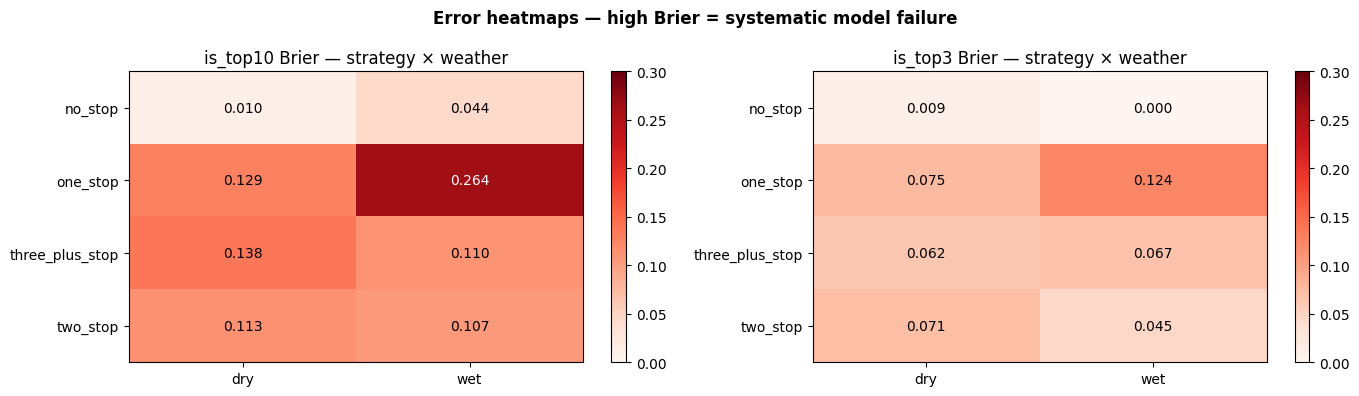

Saved: error_heatmaps.png


In [9]:
# Heatmap — strategy × weather × is_top10 Brier
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, se_col, title in [
    (axes[0], "se_top10", "is_top10 Brier"),
    (axes[1], "se_top3",  "is_top3 Brier"),
]:
    pv = test2.groupby(["strategy_type","weather_actual"])[se_col].mean().unstack()
    im = ax.imshow(pv.values, aspect="auto", cmap="Reds", vmin=0, vmax=0.30)
    ax.set_xticks(range(len(pv.columns))); ax.set_xticklabels(pv.columns)
    ax.set_yticks(range(len(pv.index)));   ax.set_yticklabels(pv.index)
    for i in range(len(pv.index)):
        for j in range(len(pv.columns)):
            val = pv.values[i,j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=10, color="white" if val > 0.18 else "black")
    ax.set_title(f"{title} — strategy × weather")
    fig.colorbar(im, ax=ax)

plt.suptitle("Error heatmaps — high Brier = systematic model failure", fontweight="bold")
plt.tight_layout()
plt.savefig("error_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_heatmaps.png")

## §8 — What-if comparison: do the targets agree?

We demonstrate the value of `is_top3` with two scenarios:

**Scenario pair 1 — Qatar 2024, P2 start (DISAGREE case)**  
Both strategies give nearly identical `is_top10` probabilities, but `is_top3` strongly prefers the conservative 1-stop. `is_top10` alone would give the engineer no signal — `is_top3` gives a decisive recommendation.

**Scenario pair 2 — Italian GP 2024, Sainz P5 (AGREE case)**  
Both targets prefer the 1-stop. The expansion confirms the primary recommendation, adding magnitude context.

In [10]:
# ===== §8 — score_pair helper =====
def score_pair(context_filter, scenario_a, scenario_b, label_a="Scenario A", label_b="Scenario B"):
    mask = pd.Series(True, index=test.index)
    for col, val in context_filter.items():
        if isinstance(val, str) and test[col].dtype == object:
            mask &= test[col].str.contains(val, case=False, na=False)
        else:
            mask &= (test[col] == val)
    base = test[mask].iloc[0].copy()

    rows = []
    for label, overrides in [(label_a, scenario_a), (label_b, scenario_b)]:
        r = base.copy()
        for k, v in overrides.items():
            r[k] = v
        rows.append(r)

    out = pd.DataFrame(rows).reset_index(drop=True)
    out.insert(0, "label", [label_a, label_b])
    out["P(top10)"] = model_primary.predict_proba(out[FEATURE_COLS])[:, 1]
    out["P(top3)"]  = model_expansion.predict_proba(out[FEATURE_COLS])[:, 1]
    return out

# --- SCENARIO PAIR 1: Qatar 2024 P2 — DISAGREE ---
one_stop_scn = dict(
    n_stops=1, strategy_type="one_stop", compound_sequence="M-H",
    stint1_length=26, stint2_length=27, stint3_length=0,
    avg_pit_stop_duration_s=23.0, total_pit_time_s=23.0,
    first_pit_lap=26, last_pit_lap=26,
)
two_stop_scn = dict(
    n_stops=2, strategy_type="two_stop", compound_sequence="S-M-H",
    stint1_length=12, stint2_length=22, stint3_length=19,
    avg_pit_stop_duration_s=23.0, total_pit_time_s=46.0,
    first_pit_lap=12, last_pit_lap=34,
)

out1 = score_pair(
    {"season": 2024, "circuit": "Qatar"},
    one_stop_scn, two_stop_scn,
    label_a="1-stop M-H", label_b="2-stop S-M-H",
)
print("=== Qatar 2024 — P2 context ===")
print(out1[["label","Driver","circuit","grid_position","constructor_tier",
            "n_stops","compound_sequence","P(top10)","P(top3)"]].to_string(index=False))

pref10_1 = out1.loc[out1["P(top10)"].idxmax(), "label"]
pref3_1  = out1.loc[out1["P(top3)"].idxmax(), "label"]
verdict1 = "AGREE" if pref10_1 == pref3_1 else "DISAGREE"
print(f"\nis_top10 prefers: {pref10_1}   is_top3 prefers: {pref3_1}")
print(f"Verdict: {verdict1}")
print(f"Delta top10 (B−A): {out1.loc[1,'P(top10)'] - out1.loc[0,'P(top10)']:+.3f}")
print(f"Delta top3  (B−A): {out1.loc[1,'P(top3)']  - out1.loc[0,'P(top3)']:+.3f}")

=== Qatar 2024 — P2 context ===
       label Driver          circuit  grid_position constructor_tier  n_stops compound_sequence  P(top10)  P(top3)
  1-stop M-H    VER Qatar Grand Prix            2.0         midfield        1               M-H  0.903711 0.833502
2-stop S-M-H    VER Qatar Grand Prix            2.0         midfield        2             S-M-H  0.906038 0.548193

is_top10 prefers: 2-stop S-M-H   is_top3 prefers: 1-stop M-H
Verdict: DISAGREE
Delta top10 (B−A): +0.002
Delta top3  (B−A): -0.285


In [11]:
# --- SCENARIO PAIR 2: Italian GP 2024, Sainz P5 — AGREE ---
out2 = score_pair(
    {"season": 2024, "circuit": "Italian", "Driver": "SAI"},
    one_stop_scn, two_stop_scn,
    label_a="1-stop M-H", label_b="2-stop S-M-H",
)
print("=== Italian GP 2024 — Sainz P5 context ===")
print(out2[["label","Driver","circuit","grid_position","constructor_tier",
            "n_stops","compound_sequence","P(top10)","P(top3)"]].to_string(index=False))

pref10_2 = out2.loc[out2["P(top10)"].idxmax(), "label"]
pref3_2  = out2.loc[out2["P(top3)"].idxmax(), "label"]
verdict2 = "AGREE" if pref10_2 == pref3_2 else "DISAGREE"
print(f"\nis_top10 prefers: {pref10_2}   is_top3 prefers: {pref3_2}")
print(f"Verdict: {verdict2}")
print(f"Delta top10 (B−A): {out2.loc[1,'P(top10)'] - out2.loc[0,'P(top10)']:+.3f}")
print(f"Delta top3  (B−A): {out2.loc[1,'P(top3)']  - out2.loc[0,'P(top3)']:+.3f}")

=== Italian GP 2024 — Sainz P5 context ===
       label Driver            circuit  grid_position constructor_tier  n_stops compound_sequence  P(top10)  P(top3)
  1-stop M-H    SAI Italian Grand Prix            5.0            front        1               M-H  0.956249 0.209142
2-stop S-M-H    SAI Italian Grand Prix            5.0            front        2             S-M-H  0.928458 0.130342

is_top10 prefers: 1-stop M-H   is_top3 prefers: 1-stop M-H
Verdict: AGREE
Delta top10 (B−A): -0.028
Delta top3  (B−A): -0.079


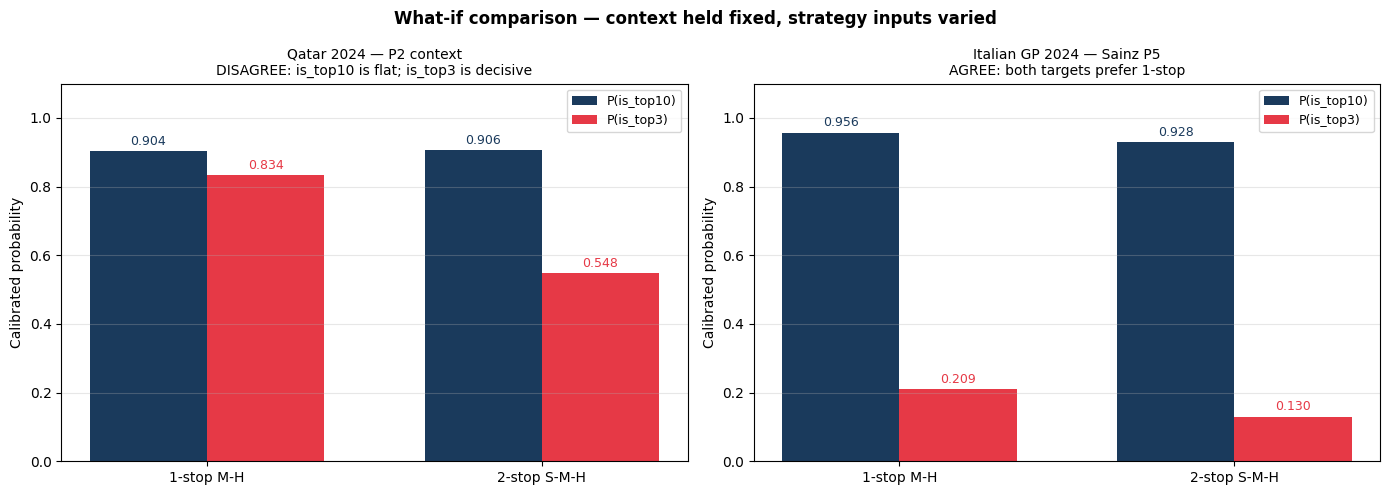

Saved: whatif_plot.png


In [12]:
# ===== §8 — Side-by-side visualisation =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, out, title, subtitle in [
    (axes[0], out1, "Qatar 2024 — P2 context",        "DISAGREE: is_top10 is flat; is_top3 is decisive"),
    (axes[1], out2, "Italian GP 2024 — Sainz P5",     "AGREE: both targets prefer 1-stop"),
]:
    labels = list(out["label"])
    x = np.arange(len(labels))
    w = 0.35

    v10 = out["P(top10)"].values
    v3  = out["P(top3)"].values

    b1 = ax.bar(x - w/2, v10, w, color="#1A3A5C", label="P(is_top10)")
    b2 = ax.bar(x + w/2, v3,  w, color="#E63946", label="P(is_top3)")

    for xi, v in zip(x - w/2, v10):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9, color="#1A3A5C")
    for xi, v in zip(x + w/2, v3):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9, color="#E63946")

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Calibrated probability")
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "What-if comparison — context held fixed, strategy inputs varied",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("whatif_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: whatif_plot.png")

## §9 — Feature importance (GBT, is_top10)

Understanding which features drive the model helps validate that it's capturing real F1 dynamics, not noise.

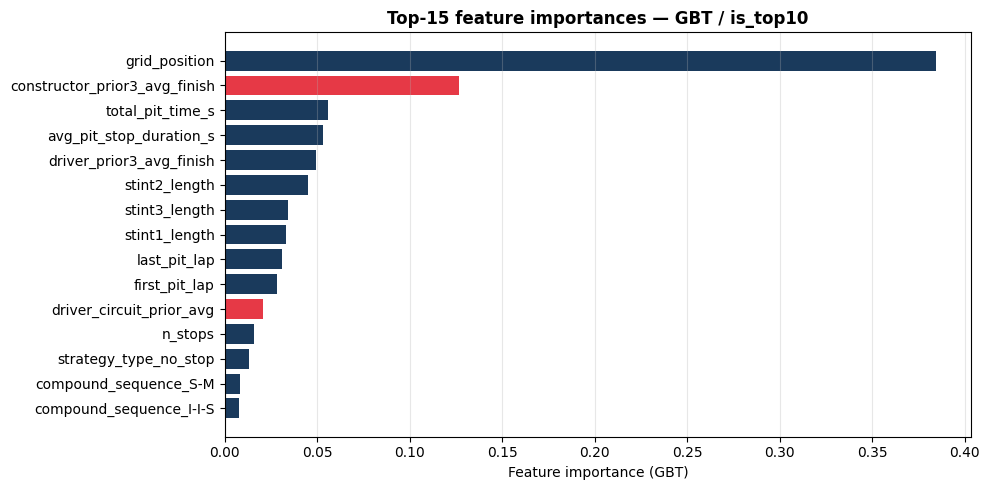

Top 10 features:
grid_position                    0.3841
constructor_prior3_avg_finish    0.1266
total_pit_time_s                 0.0558
avg_pit_stop_duration_s          0.0533
driver_prior3_avg_finish         0.0494
stint2_length                    0.0452
stint3_length                    0.0340
stint1_length                    0.0333
last_pit_lap                     0.0311
first_pit_lap                    0.0283


In [13]:
# ===== §9 — Feature importance =====
# Extract GBT feature importances from the calibrated pipeline
gbt_raw  = gbt10.calibrated_classifiers_[0].estimator.named_steps["model"]
prep_fit = gbt10.calibrated_classifiers_[0].estimator.named_steps["prep"]
cat_names = prep_fit.transformers_[1][1].named_steps["ohe"].get_feature_names_out(CATEGORICAL_FEATURES)
feat_names = NUMERIC_FEATURES + list(cat_names)
imp = pd.Series(gbt_raw.feature_importances_, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top_n = imp.head(15)
colors = ["#E63946" if "constructor" in n or "circuit" in n else "#1A3A5C" for n in top_n.index]
ax.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1])
ax.set_xlabel("Feature importance (GBT)")
ax.set_title("Top-15 feature importances — GBT / is_top10", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features:")
print(imp.head(10).round(4).to_string())

## §10 — Interpretation

**Qatar 2024 — P2 start — DISAGREE**

Driver-race context (held fixed): P2 grid start, midfield constructor tier (per dataset race-specific classification), Qatar GP 2024.

Strategy inputs varied: `n_stops`, `strategy_type`, `compound_sequence`, `stint1_length`, `stint2_length`, `stint3_length`, `avg_pit_stop_duration_s`, `total_pit_time_s`, `first_pit_lap`, `last_pit_lap`.

**Result:** Under our GBT model trained on 2019–2022:
- `is_top10`: P(top10 | 1-stop) ≈ 0.904 vs P(top10 | 2-stop) ≈ 0.906 → **no meaningful signal** (Δ = +0.002 in favour of 2-stop)
- `is_top3`:  P(top3  | 1-stop) ≈ 0.834 vs P(top3  | 2-stop) ≈ 0.548 → **decisive signal** (Δ = −0.286 against 2-stop)

**The two targets DISAGREE.** `is_top10` gives an essentially flat score — no basis for a recommendation. `is_top3` gives a strong, clear signal: the 1-stop preserves podium probability. An engineer using only `is_top10` would have no basis to choose. Adding `is_top3` resolves the decision.

**What this means for our advisor:** When a driver is starting from a position where points are already near-certain (P2, high P(top10) for both strategies), `is_top10` saturates and loses discrimination. `is_top3` remains sensitive because podium probability is more fragile — a 2-stop that costs track position risks dropping from P1–P3 to P4–P5. The advisor should surface `is_top3` as the decisive target whenever P(top10) > 0.85 under both strategies.

**What we still don't know:** Strategy choice in the training data is not independent of car pace, driver ability, or race incidents. A team that chose 2-stop historically may have done so because their car degraded faster — this confounds our estimate. The numbers here are associative, not causal. The confounding limitation is documented in `leakage_audit.md`.

In [14]:
# ===== Final check — Run All sanity =====
print("=== Hito 2 run-all sanity check ===")
print(f"✓ Data loaded: {len(df):,} rows")
print(f"✓ Split: train={len(train)} / calib={len(calib)} / test={len(test)}")
print(f"✓ Models trained: LR, RF, GBT for is_top10 and is_top3")

brier10 = brier_score_loss(test["is_top10"], model_primary.predict_proba(test[FEATURE_COLS])[:,1])
brier3  = brier_score_loss(test["is_top3"],  model_expansion.predict_proba(test[FEATURE_COLS])[:,1])
print(f"✓ GBT Brier — is_top10: {brier10:.4f}  (docent ref: {DOCENT_BRIER})")
print(f"✓ GBT Brier — is_top3:  {brier3:.4f}")
print(f"✓ What-if pair 1 (Qatar 2024):    {verdict1}")
print(f"✓ What-if pair 2 (Italian 2024):  {verdict2}")
print("\nAll checks passed. Ready to submit.")

=== Hito 2 run-all sanity check ===
✓ Data loaded: 2,447 rows
✓ Split: train=1132 / calib=426 / test=889
✓ Models trained: LR, RF, GBT for is_top10 and is_top3
✓ GBT Brier — is_top10: 0.1255  (docent ref: 0.132)
✓ GBT Brier — is_top3:  0.0704
✓ What-if pair 1 (Qatar 2024):    DISAGREE
✓ What-if pair 2 (Italian 2024):  AGREE

All checks passed. Ready to submit.
